In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold

In [23]:
import kagglehub

path = kagglehub.dataset_download(
    "kmader/skin-cancer-mnist-ham10000"
)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.
Path to dataset files: /kaggle/input/skin-cancer-mnist-ham10000


In [24]:
dataset_path = Path(path)
metadata_path = next(dataset_path.rglob("HAM10000_metadata.csv"))
image_dirs = sorted(dataset_path.rglob("HAM10000_images_part_*"))

# Load metadata
metadata = pd.read_csv(metadata_path)

label_names = {
    "akiec": "Actinic keratoses",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions",
}

metadata["class_name"] = metadata["dx"].map(label_names)

print("Dataset size:", len(metadata))
display(metadata.head())

Dataset size: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization,class_name
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,Benign keratosis
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,Benign keratosis
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,Benign keratosis
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,Benign keratosis
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,Benign keratosis


In [25]:
# Class counts and percentages
class_counts = (
    metadata["class_name"]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="images")
)

class_counts["percentage"] = (
    class_counts["images"] / len(metadata) * 100
).round(2)

display(class_counts)

,class,images,percentage
0,Melanocytic nevi,6705,66.95
1,Melanoma,1113,11.11
2,Benign keratosis,1099,10.97
3,Basal cell carcinoma,514,5.13
4,Actinic keratoses,327,3.27
5,Vascular lesions,142,1.42
6,Dermatofibroma,115,1.15


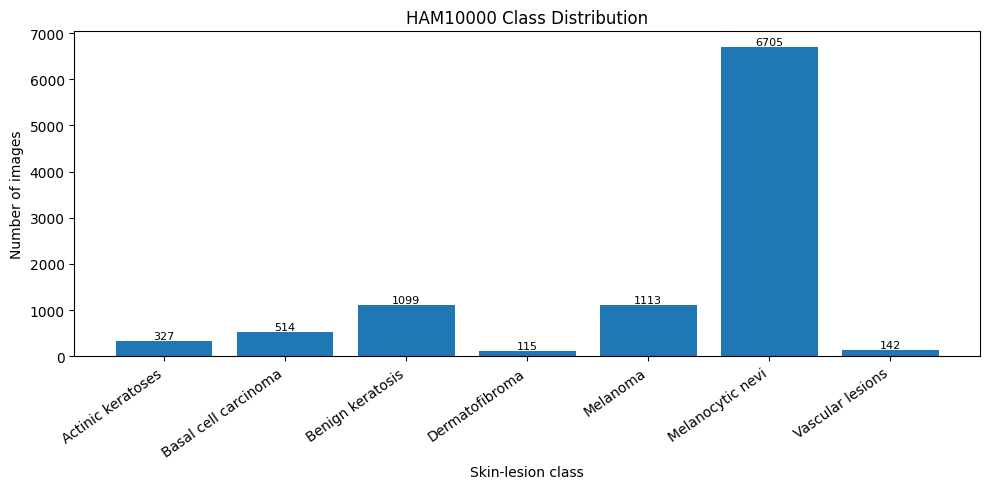

In [26]:
# plot 1: class distribution
ordered_classes = [label_names[key] for key in label_names]
counts = (
    metadata["class_name"]
    .value_counts()
    .reindex(ordered_classes)
)

plt.figure(figsize=(10, 5))
bars = plt.bar(counts.index, counts.values)

plt.title("HAM10000 Class Distribution")
plt.xlabel("Skin-lesion class")
plt.ylabel("Number of images")
plt.xticks(rotation=35, ha="right")

for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        str(value),
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=200)
plt.show()


# Find an image file by image_id
def find_image(image_id):
    for image_dir in image_dirs:
        image_file = image_dir / f"{image_id}.jpg"
        if image_file.exists():
            return image_file

    raise FileNotFoundError(f"Image not found: {image_id}")

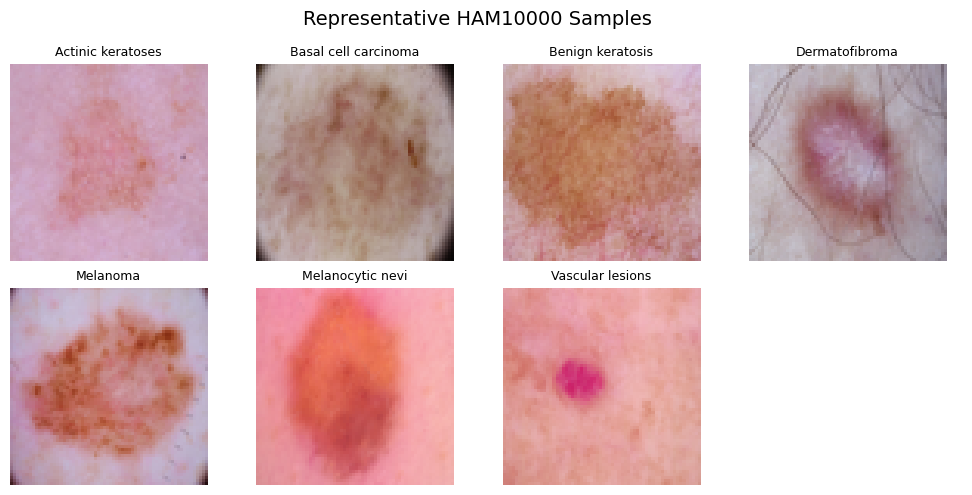

In [27]:
# Plot 2: one representative sample per class

samples_per_class = 1
ncols = 4
nrows = (len(ordered_classes) + ncols - 1) // ncols

selected_samples = pd.concat(
    [
        group.sample(
            n=samples_per_class,
            random_state=42,
        )
        for _, group in metadata.groupby("class_name")
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(10, 5),
)

axes = axes.flatten()

for index, class_name in enumerate(ordered_classes):
    class_samples = selected_samples[
        selected_samples["class_name"] == class_name
    ]

    axis = axes[index]
    axis.axis("off")

    record = class_samples.iloc[0]
    image_file = find_image(record["image_id"])

    with Image.open(image_file) as image:
        image = image.convert("RGB").resize((64, 64))
        axis.imshow(image)

    axis.set_title(class_name, fontsize=9)

# Hide the unused subplot
for axis in axes[len(ordered_classes):]:
    axis.axis("off")

fig.suptitle("Representative HAM10000 Samples", fontsize=14)
plt.tight_layout()
plt.savefig("sample_grid.png", dpi=200, bbox_inches="tight")
plt.show()

In [28]:
# train/validation/test split:
groups = (
    metadata["lesion_id"]
    if "lesion_id" in metadata.columns
    else metadata["image_id"]
)

splitter = StratifiedGroupKFold(
    n_splits=20,
    shuffle=True,
    random_state=42,
)

fold_ids = pd.Series(
    index=metadata.index,
    dtype="int64",
)

for fold, (_, held_out_indices) in enumerate(
    splitter.split(metadata, metadata["dx"], groups)
):
    fold_ids.iloc[held_out_indices] = fold

metadata["split"] = fold_ids.map(
    lambda fold: (
        "train"
        if fold < 14
        else "validation"
        if fold < 17
        else "test"
    )
)

# Save the planned split
Path("data").mkdir(exist_ok=True)

train_data = metadata[metadata["split"] == "train"]
validation_data = metadata[metadata["split"] == "validation"]
test_data = metadata[metadata["split"] == "test"]

train_data.to_csv("train.csv", index=False)
validation_data.to_csv("validation.csv", index=False)
test_data.to_csv("test.csv", index=False)

print("Split totals:")
display(metadata["split"].value_counts())

print("Class distribution by split:")
display(pd.crosstab(metadata["class_name"], metadata["split"]))

Split totals:


,count
split,
train,6984
validation,1524
test,1507


Class distribution by split:


split,test,train,validation
class_name,,,
Actinic keratoses,36,223,68
Basal cell carcinoma,71,338,105
Benign keratosis,185,772,142
Dermatofibroma,22,80,13
Melanocytic nevi,978,4728,999
Melanoma,187,737,189
Vascular lesions,28,106,8


In [29]:
from google.colab import files

files.download("train.csv")
files.download("validation.csv")
files.download("test.csv")

files.download("class_distribution.png")
files.download("sample_grid.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>